# Parallel adjoint with a waveguide bend

Adjoint methods are a core tool for inverse design, where the goal is to efficiently compute gradients of an objective with respect to many design parameters. In the standard adjoint workflow, Tidy3D first runs the forward simulation and then constructs the required adjoint simulations on the fly from the recorded monitor data. At that point, it determines which adjoint simulations are needed to obtain the requested gradients and runs them afterward.

For some supported monitor outputs, however, the required adjoint simulations are known in advance and do not depend on the forward result. In those cases, Tidy3D can prepare one or more adjoint simulations, launch them in parallel with the forward simulation, and combine them with the forward data afterward. This is the idea behind parallel adjoint.

To use parallel adjoint efficiently, the simulation has to be set up such that it is already clear beforehand which adjoint simulations will be needed. In practice, this means using only supported and gradient-relevant monitor outputs, and restricting those outputs to the data that actually enters the objective.

When the supported adjoint work dominates the total runtime, this can lead to a speedup approaching 2x. In this notebook, we use a simple 2D waveguide bend as a toy example and compare the runtime of a single gradient evaluation with parallel adjoint switched off and on.

If you are new to autograd in Tidy3D, useful general introductions are [Autograd0Overview](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0Overview/), [Autograd0Quickstart](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0Quickstart/), [Autograd1Intro](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd1Intro/), and [Autograd2GradientChecking](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd2GradientChecking/).

<img src="./img/adjoint_30.png" style="width:65%;" alt="Schematic comparing regular adjoint and parallel adjoint workflows.">


In [225]:
import time

import autograd as ag
import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web
from tidy3d.config import config

# make sure that runtime measures are not impacted by caching
td.config.web.enable_caching = False
td.config.local_cache.enabled = False

## Setup

As a simple toy example, we use a 90 degree SiN waveguide bend and measure the gradient of the transmitted mode power with respect to a single geometric parameter. The parameter controls the waveguide width near the middle of the bend and tapers linearly back to the nominal width at the input and output.

The point here is not this particular parameterization. It is just a compact example that makes the `parallel adjoint` workflow easy to see.

We use a clean 2D approximation of the bend. The simulation is invariant in `z`, so the computational domain is collapsed with `size=(Lx, Ly, 0)`, PML is applied only in `x` and `y`, and we use a uniform cladding background for the 2D model.


In [226]:
wavelength = 1.55
freq0 = td.C_0 / wavelength
fwidth = freq0 / 8
monitor_freq = freq0

# discretization of the bend profile
num_pts = 40
angles = np.linspace(0, np.pi / 2, num_pts + 2)[1:-1]
bend_position = np.linspace(0.0, 1.0, num_pts + 2)[1:-1]
middle_weight = 1.0 - np.abs(2.0 * bend_position - 1.0)

# refractive indices
n_wg = 2.0
n_sub = 1.5

# geometric parameters
design_buffer = 1.0 * wavelength
straight_length = 1.0 * wavelength
h = 0.7
wg_width = 1.5
middle_width_max = 2.3
radius = 6.0

# simulation and mode settings
monitor_name = "mode"
min_steps_per_wvl = 20
num_modes = 3
mode_spec = td.ModeSpec(num_modes=num_modes)

From these values, we can define the simulation size.


In [227]:
outer_radius_max = radius + middle_width_max / 2
Lx = Ly = straight_length + outer_radius_max + design_buffer
Lz = design_buffer + h + design_buffer

middle_width0 = 2.0

## Bend Parameterization

Here we define how our waveguide bend is built dependent on a single parameter by defining vertex positions. Note that this parametrization is just for demonstration purposes.

We keep the ends of the bend fixed and vary only the width towards the center. The bend starts with the nominal width at both ends, reaches a parameter-defined width at 45 degrees, and changes linearly along the arc.

For a more deliberate waveguide-bend parametrization, see [Autograd8WaveguideBend](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd8WaveguideBend/).


In [228]:
def section_widths(middle_width):
    """Waveguide width along the bend."""
    return wg_width + (middle_width - wg_width) * middle_weight


def make_vertices(middle_width):
    """Polygon vertices for the bend."""
    widths = section_widths(middle_width)
    outer_radii = radius + widths / 2
    inner_radii = radius - widths / 2

    x0 = -Lx / 2 + straight_length
    y0 = -Ly / 2 + straight_length

    vertices = []

    vertices.append((-Lx / 2 + 1e-2, y0 + radius + wg_width / 2))
    vertices.append((x0, y0 + radius + wg_width / 2))

    for angle, outer_radius in zip(angles, outer_radii):
        x = outer_radius * np.sin(angle) + x0
        y = outer_radius * np.cos(angle) + y0
        vertices.append((x, y))

    vertices.append((x0 + radius + wg_width / 2, y0))
    vertices.append((x0 + radius + wg_width / 2, -Ly / 2 + 1e-2))
    vertices.append((x0 + radius - wg_width / 2, -Ly / 2 + 1e-2))
    vertices.append((x0 + radius - wg_width / 2, y0))

    for angle, inner_radius in zip(angles[::-1], inner_radii[::-1]):
        x = inner_radius * np.sin(angle) + x0
        y = inner_radius * np.cos(angle) + y0
        vertices.append((x, y))

    vertices.append((x0, y0 + radius - wg_width / 2))
    vertices.append((-Lx / 2 + 1e-2, y0 + radius - wg_width / 2))
    return vertices


def make_polyslab(middle_width):
    """`PolySlab` representation of the bend."""
    return td.PolySlab(vertices=make_vertices(middle_width), slab_bounds=(-h / 2, h / 2), axis=2)


def make_bend(middle_width):
    """Waveguide bend structure."""
    return td.Structure(
        geometry=make_polyslab(middle_width),
        medium=td.Medium(permittivity=n_wg**2),
    )

## Sources, Monitors, and Simulation

Here, we add short straight input and output waveguide sections around the bend and then define the source, monitor, and full 2D simulation. The straight sections serve as clean ports: the `ModeSource` launches a guided mode from the input arm, and the ModeMonitor measures the outgoing modal amplitude on the output arm after the bend. The source and monitor planes are made slightly wider than the nominal waveguide using design_buffer so the modal fields are captured comfortably. Finally, `make_sim()` assembles the full simulation with the bend geometry, the two straight access waveguides, a uniform substrate-index background for the 2D model, automatic meshing, and PML boundaries in x and y.


In [230]:
box_in = td.Box.from_bounds(
    rmin=(-Lx / 2 - 1, -Ly / 2 + straight_length + radius - wg_width / 2, -h / 2),
    rmax=(
        -Lx / 2 + straight_length + 1e-3,
        -Ly / 2 + straight_length + radius + wg_width / 2,
        +h / 2,
    ),
)
box_out = td.Box.from_bounds(
    rmin=(-Lx / 2 + straight_length + radius - wg_width / 2, -Ly / 2 - 1, -h / 2),
    rmax=(-Lx / 2 + straight_length + radius + wg_width / 2, -Ly / 2 + straight_length, +h / 2),
)

wg_in = td.Structure(geometry=box_in, medium=td.Medium(permittivity=n_wg**2))
wg_out = td.Structure(geometry=box_out, medium=td.Medium(permittivity=n_wg**2))
sim_medium = td.Medium(permittivity=n_sub**2)

mode_width = wg_width + 2 * design_buffer
mode_height = Lz

mode_src = td.ModeSource(
    size=(0, mode_width, mode_height),
    center=(-Lx / 2 + straight_length / 2, -Ly / 2 + straight_length + radius, 0),
    direction="+",
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
)

mode_mnt = td.ModeMonitor(
    size=(mode_width, 0, mode_height),
    center=(-Lx / 2 + straight_length + radius, -Ly / 2 + straight_length / 2, 0),
    name=monitor_name,
    freqs=[monitor_freq],
    mode_spec=mode_spec,
)


def make_sim(middle_width):
    return td.Simulation(
        size=(Lx, Ly, 0),
        medium=sim_medium,
        structures=[wg_in, wg_out, make_bend(middle_width)],
        sources=[mode_src],
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl),
        boundary_spec=td.BoundarySpec.pml(x=True, y=True, z=False),
        monitors=[mode_mnt],
        run_time=10 / fwidth,
    )

Let's visualize our experimental setup to review the correct arrangement of our components.

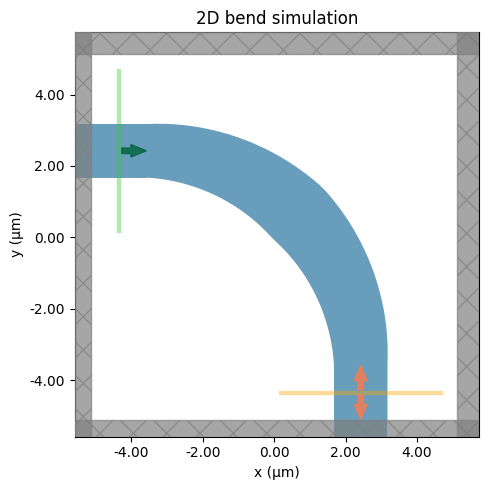

In [231]:
# the bend overlaps slightly with the straight waveguide sections by construction. Ignore this warning.
td.config.logging.level = "ERROR"
sim = make_sim(middle_width0)

fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)
sim.plot(z=0.0, ax=ax)
ax.set_title("2D bend simulation")
plt.show()

## Select the Mode of Interest

Next, we solve for a few modes on the input waveguide cross section and assume that we are interested in the mode that appears as `mode_index=2`. We then tighten the source and monitor setup around this physical mode before the differentiable simulation by using `to_source` on the `ModeSolver` result and by defining `ModeSpec(num_modes=1, target_neff=target_neff)`.

This is the key step that makes the example compatible with `parallel adjoint`: the target mode is fixed before the forward run, so the required adjoint simulation is already known. After tightening the mode specification, the same physical mode is tracked as `mode_index=0` in the differentiable simulation.

This matters because parallel adjoint prepares adjoint simulations from the monitor outputs that may contribute to the objective. If we kept `ModeSpec(num_modes=3)` and only selected one mode afterward inside the objective, Tidy3D would still need to prepare adjoint simulations for all three monitored mode indices. By shrinking the `ModeSpec` to the one mode we actually use, the `ModeMonitor` contributes only one adjoint simulation in this example.


In [ ]:
from tidy3d.plugins.mode import ModeSolver

ms = ModeSolver(simulation=sim, plane=mode_src, mode_spec=mode_spec, freqs=[freq0])
mode_data = ms.solve()

print("Effective index of computed modes:", np.array(mode_data.n_eff))

In [233]:
target_mode_index = 2
target_neff = float(np.real(np.array(mode_data.n_eff).squeeze()[target_mode_index]))

# Restrict the differentiable simulation to the one physical mode we want.
# After tightening the ModeSpec, this target mode is tracked as mode_index = 0.
mode_src = ms.to_source(
    mode_index=target_mode_index,
    source_time=mode_src.source_time,
    direction=mode_src.direction,
)
mode_spec = td.ModeSpec(num_modes=1, target_neff=target_neff)
mode_mnt = mode_mnt.updated_copy(mode_spec=mode_spec)
mode_index = 0

# at the output plane, the guided wave travels in the negative monitor direction
output_direction = "-"

print(f"Targeting the mode that appeared as mode_index={target_mode_index} in the initial solve.")
print(f"Using ModeSpec(num_modes=1, target_neff={target_neff:.4f}) for the differentiable run.")

Targeting the mode that appeared as mode_index=2 in the initial solve.
Using ModeSpec(num_modes=1, target_neff=1.8282) for the differentiable run.


## Objective Function

Our figure of merit is the transmission of the selected output mode at a single target frequency.


In [234]:
def objective(middle_width):
    sim = make_sim(middle_width)
    sim_data = web.run(
        sim,
        task_name="bend",
        verbose=False,
    )

    amps = (
        sim_data[monitor_name]
        .amps.sel(
            direction=output_direction,
            mode_index=mode_index,
        )
        .values
    )
    transmission = anp.abs(anp.array(amps)) ** 2
    return anp.sum(transmission)


value_and_grad = ag.value_and_grad(objective)

Next, we define a small helper that toggles the relevant adjoint settings and measures the runtime of one gradient evaluation. Note that we can use the `with config as cfg:` context to use temporary changes which are reverted after leaving the `with` block.


In [235]:
def timed_value_and_grad(middle_width, parallel_run):
    with config as cfg:  # optional context manager to ensure temporary changes
        cfg.adjoint.local_gradient = (
            True  # note that parallel adjoint is currently only supported with local gradients
        )
        cfg.adjoint.parallel_run = parallel_run

        t0 = time.perf_counter()
        value, grad = value_and_grad(middle_width)
        elapsed = time.perf_counter() - t0

    return {
        "value": float(value),
        "grad": float(grad),
        "elapsed": elapsed,
    }

## Compare Sequential and Parallel Adjoint

We now evaluate the same gradient twice: once with `parallel adjoint` disabled, and once with it enabled.

In [236]:
result_parallel = timed_value_and_grad(middle_width0, parallel_run=True)
result_sequential = timed_value_and_grad(middle_width0, parallel_run=False)

print(f"{'method':<20}{'objective':>14}{'gradient':>14}{'time [s]':>14}")
print("-" * 62)
print(
    f"{'sequential adjoint':<20}"
    f"{result_sequential['value']:>14.4e}"
    f"{result_sequential['grad']:>14.4e}"
    f"{result_sequential['elapsed']:>14.2f}"
)
print(
    f"{'parallel adjoint':<20}"
    f"{result_parallel['value']:>14.4e}"
    f"{result_parallel['grad']:>14.4e}"
    f"{result_parallel['elapsed']:>14.2f}"
)
print()
print(f"speedup = {result_sequential['elapsed'] / result_parallel['elapsed']:.2f}x")

method                   objective      gradient      time [s]
--------------------------------------------------------------
sequential adjoint      3.8935e-01    3.5744e-01         67.91
parallel adjoint        3.8935e-01    3.5748e-01         35.21

speedup = 1.93x


In a successful run, the objective value and gradient should agree between the two evaluations (plus some numerical noise), while the parallel run finishes sooner.

The achievable speedup is not determined only by the pure simulation time. It also depends on how much of the total wall-clock time is spent in work that cannot be overlapped: constructing the simulations, uploading them, monitoring them, downloading the results, and the local postprocessing that combines forward and adjoint data. If these fixed costs are large compared to the actual solver runtime, the observed speedup will be smaller. If the supported adjoint work dominates the runtime, the speedup can approach 2x.


## Rules and Guardrails

Parallel adjoint is controlled through the standard adjoint configuration. The direction policy determines how many mode directions are prepared for a `ModeMonitor`, and `max_num_adjoint_per_fwd` sets the per-run cap for parallel adjoint work.

Supported monitor outputs:

- `ModeMonitor` amplitudes.
- `DiffractionMonitor` amplitudes.
- point `FieldMonitor` probes with `size=(0, 0, 0)` and `colocate=True`.

If any unsupported monitor is present in the differentiable simulation, Tidy3D falls back to the sequential adjoint pipeline for that run.
Unsupported monitors include:

- planar or volumetric `FieldMonitor` outputs.
- All other monitors which are not listed above.

Direction policy for `ModeMonitor` outputs:

- `"assume_outgoing"` is the default. Tidy3D infers the outgoing mode direction from the monitor position relative to the simulation center and keeps only the mode that points away from the center toward the outer simulation bounds. This avoids running adjoint simulations for the other direction.
- `"run_both_directions"` prepares both `"+"` and `"-"` directions for each monitored mode. Use this if you are not sure in which direction the mode propagates across the monitor. Tidy3D will then run adjoint simulations for both directions, which increases the mode-monitor part of the parallel adjoint work.

How many parallel adjoint simulations can be produced?

- `ModeMonitor`: one basis per `(freq, mode_index, direction)`. With `"assume_outgoing"`, this is `num_freqs * num_modes`. With `"run_both_directions"`, this becomes `2 * num_freqs * num_modes`.
- `DiffractionMonitor`: one basis per `(freq, order_x, order_y, polarization)` for propagating orders only. In practice this is typically `2 * num_freqs * num_propagating_orders`, because the polarizations are `s` and `p`.
- point `FieldMonitor`: one basis per `(freq, field_component)`, so `num_freqs * num_components` for the selected components among `Ex`, `Ey`, `Ez`, `Hx`, `Hy`, and `Hz`.
- Tidy3D then groups compatible bases by port, so the number of launched adjoint simulations can be smaller than the basis count.
- If the grouped count exceeds `config.adjoint.max_adjoint_per_fwd`, parallel adjoint is disabled and Tidy3D falls back to the sequential path.

Practical guidance:

- Include only monitors in the differentiable simulation that are actually used for the gradient calculation.
- Restrict each supported monitor to the essential data that enters the objective, such as the mode of interest, the relevant frequency, or the needed field components.
- Place `ModeMonitor` outputs such that the mode of interest points away from the simulation center toward the outer boundary. This makes efficient use of the default `"assume_outgoing"` policy.


For more general autograd workflows:

- [Autograd0Overview](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0Overview/)
- [Autograd0Quickstart](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0Quickstart/)
- [Autograd1Intro](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd1Intro/)
- [Autograd2GradientChecking](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd2GradientChecking/)
- [Autograd3InverseDesign](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd3InverseDesign/)

For more waveguide bend examples:

- [Autograd8WaveguideBend](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd8WaveguideBend/)
- [Autograd18TopologyBend](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd18TopologyBend/)
